# Chapter 11: neural networks that understand language: king – man + woman == ?

Haikal Ali TK-46-GAB 1103223071

## In this chapter

- Natural language processing (NLP)
- Supervised NLP
- Capturing word correlation in input data
- Intro to an embedding layer
- Neural architecture
- Comparing word embeddings
- Filling in the blank
- Meaning is derived from loss
- Word analogies

## What does it mean to understand language?

Sampai chapter sebelumnya, neural networks dipakai untuk memodelkan image data. Namun, neural networks juga dapat digunakan untuk memahami jenis dataset lain.

Chapter ini mulai masuk ke bidang **natural language processing (NLP)**, yaitu bidang yang berfokus pada automated understanding of human language. Pembahasan berfokus pada pendekatan deep learning terhadap NLP.

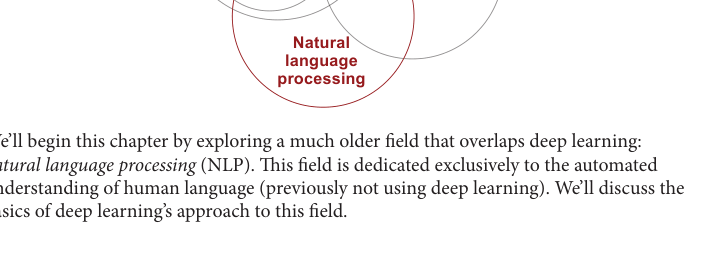

## Natural language processing (NLP)

NLP terbagi menjadi banyak tasks atau challenges.

Beberapa contoh classification problem umum dalam NLP:

- Menggunakan characters dalam document untuk memprediksi batas awal dan akhir kata.
- Menggunakan words dalam document untuk memprediksi batas awal dan akhir kalimat.
- Menggunakan words dalam sentence untuk memprediksi part of speech setiap kata.
- Menggunakan words dalam sentence untuk memprediksi awal dan akhir phrases.
- Menggunakan words dalam sentence untuk memprediksi named entity references.
- Menggunakan sentences dalam document untuk memprediksi pronouns yang merujuk ke orang, tempat, atau benda yang sama.
- Menggunakan words dalam sentence untuk memprediksi sentiment sentence.

Secara umum, NLP tasks melakukan salah satu dari tiga hal: memberi label pada region of text, menghubungkan dua atau lebih region of text, atau mengisi informasi yang hilang berdasarkan context.

Machine learning dan NLP sangat berkaitan. Sebelum deep learning populer, banyak state-of-the-art NLP algorithms berbasis advanced probabilistic non-parametric models. Dalam perkembangan terbaru, dua neural algorithms menjadi penting dalam NLP: **neural word embeddings** dan **recurrent neural networks (RNNs)**.

Chapter ini membangun word-embedding algorithm dan menunjukkan mengapa embedding dapat meningkatkan akurasi NLP algorithms. Chapter berikutnya akan membahas recurrent neural network untuk prediction across sequences.

## Supervised NLP

Dalam supervised NLP, words masuk sebagai input dan predictions keluar sebagai output.

Supervised learning mengambil “what you know” lalu mengubahnya menjadi “what you want to know”. Sejauh ini, input selalu berupa angka. Dalam NLP, input berupa text, sehingga text perlu diubah menjadi bentuk numerik.

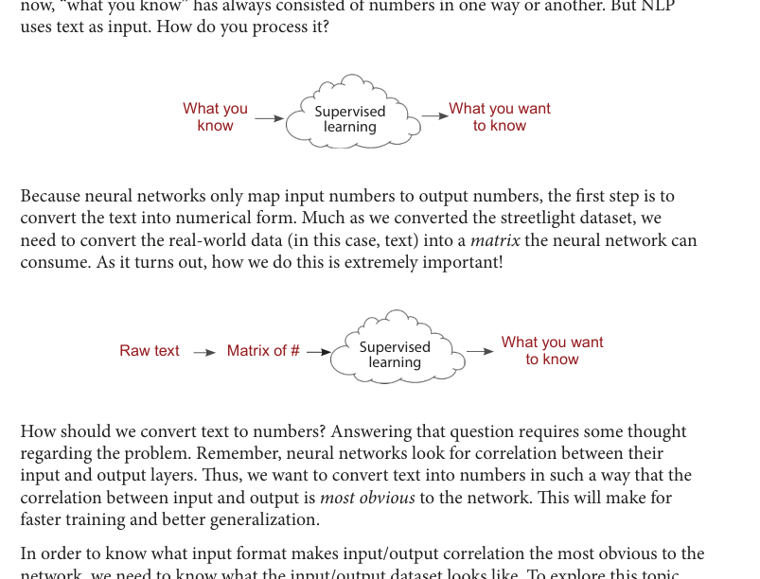

Karena neural networks hanya memetakan input numbers ke output numbers, langkah pertama adalah mengubah text menjadi matrix yang dapat diproses network.

Cara mengubah text menjadi numbers sangat penting. Neural networks mencari correlation antara input layer dan output layer. Maka, text harus diubah menjadi numbers dengan cara yang membuat correlation antara input dan output paling jelas bagi network.

Untuk membahas ini, chapter memakai task **topic classification** atau sentiment classification pada dataset movie reviews.

## IMDB movie reviews dataset

IMDB movie reviews dataset adalah kumpulan pasangan review → rating.

Contoh bentuk datanya adalah review text sebagai input dan rating sebagai output. Dataset lengkap berisi sekitar 50.000 pasangan. Rating berada antara 1 sampai 5 stars, dan dataset ini dianggap sebagai sentiment dataset karena stars menunjukkan sentiment dari review.

Output dataset berupa angka, sehingga lebih mudah diproses. Range stars dapat diubah menjadi antara 0 dan 1 agar dapat menggunakan binary softmax.

Input data lebih sulit karena berupa raw text, yaitu list of characters dengan panjang yang bervariasi. Neural networks sejauh ini menerima input fixed-size, sehingga raw input perlu diubah.

Pertanyaan pentingnya adalah: properti apa dari text yang berkorelasi dengan output?

Characters individual kemungkinan tidak punya correlation kuat dengan sentiment. Words lebih masuk akal. Kata seperti `terrible` dan `unconvincing` mungkin memiliki negative correlation dengan rating. Semakin sering kata tersebut muncul dalam review, rating cenderung menurun.

Karena itu, chapter mengeksplorasi apakah words sendiri, bahkan tanpa context, memiliki correlation yang cukup dengan sentiment.

## Capturing word correlation in input data

Pendekatan pertama adalah **bag of words**: menggunakan vocabulary review untuk memprediksi sentiment.

Jika vocabulary dari review berkorelasi dengan rating, maka input matrix dapat dibuat dengan setiap row mewakili satu movie review dan setiap column mewakili apakah review tersebut mengandung word tertentu.

Jika vocabulary berisi 2.000 words, maka setiap review vector memiliki 2.000 dimensions. Nilai 1 berarti word ada dalam review, sedangkan 0 berarti word tidak ada.

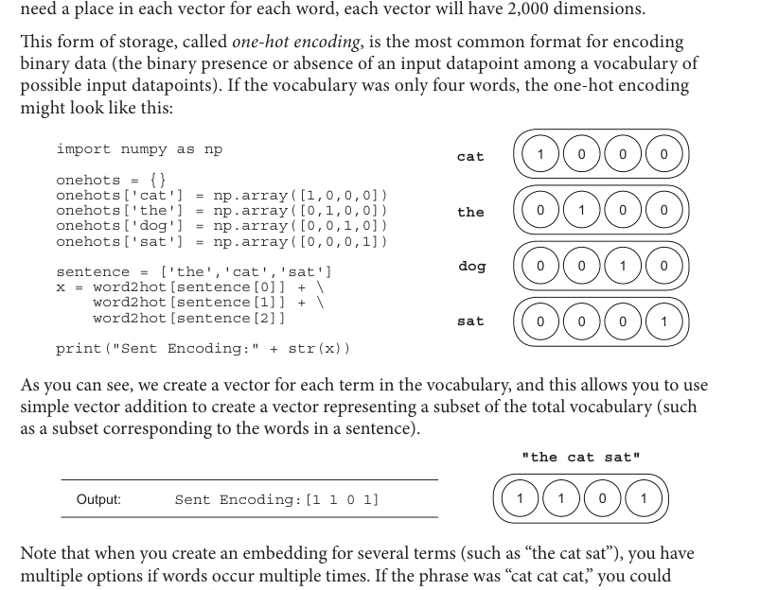

Format seperti ini disebut **one-hot encoding**, yaitu format umum untuk merepresentasikan binary presence/absence dari sebuah datapoint dalam vocabulary.

In [1]:
import numpy as np

onehots = {}
onehots["cat"] = np.array([1, 0, 0, 0])
onehots["the"] = np.array([0, 1, 0, 0])
onehots["dog"] = np.array([0, 0, 1, 0])
onehots["sat"] = np.array([0, 0, 0, 1])

# Di buku, dictionary dibuat sebagai onehots tetapi dipanggil sebagai word2hot.
# Notebook ini memakai alias agar kode berjalan.
word2hot = onehots

sentence = ["the", "cat", "sat"]

x = (
  word2hot[sentence[0]] +
  word2hot[sentence[1]] +
  word2hot[sentence[2]]
)

print("Sent Encoding:" + str(x))

Sent Encoding:[1 1 0 1]


Jika sebuah phrase berisi kata yang sama beberapa kali, ada dua pilihan: menjumlahkan vector kata tersebut berkali-kali atau mengambil unique word satu kali saja. Untuk language, penggunaan unique word biasanya bekerja lebih baik.

## Predicting movie reviews

Dengan encoding strategy tersebut dan network sebelumnya, sentiment dapat diprediksi.

Kode berikut melakukan preprocessing untuk `reviews.txt` dan `labels.txt`. File tersebut harus tersedia di working directory Colab. Jika belum ada, cell akan meminta upload file.

In [2]:
from pathlib import Path

def ensure_review_files():
  reviews_path = Path("reviews.txt")
  labels_path = Path("labels.txt")

  if reviews_path.exists() and labels_path.exists():
    return reviews_path, labels_path

  try:
    from google.colab import files
    print("Upload file reviews.txt dan labels.txt dari dataset chapter ini.")
    files.upload()
  except Exception:
    pass

  if not reviews_path.exists() or not labels_path.exists():
    raise FileNotFoundError(
      "reviews.txt dan labels.txt belum ditemukan. Letakkan kedua file tersebut di working directory Colab, lalu jalankan ulang cell ini."
    )

  return reviews_path, labels_path

reviews_path, labels_path = ensure_review_files()
print("Dataset siap:", reviews_path, labels_path)

Upload file reviews.txt dan labels.txt dari dataset chapter ini.


FileNotFoundError: reviews.txt dan labels.txt belum ditemukan. Letakkan kedua file tersebut di working directory Colab, lalu jalankan ulang cell ini.

In [ ]:
import sys

reviews_path, labels_path = ensure_review_files()

with open(reviews_path, "r", encoding="utf-8") as f:
  raw_reviews = f.readlines()

with open(labels_path, "r", encoding="utf-8") as f:
  raw_labels = f.readlines()

tokens = list(map(lambda x: set(x.split(" ")), raw_reviews))

vocab = set()

for sent in tokens:
  for word in sent:
    if len(word) > 0:
      vocab.add(word)

vocab = list(vocab)

word2index = {}

for i, word in enumerate(vocab):
  word2index[word] = i

input_dataset = []

for sent in tokens:
  sent_indices = []

  for word in sent:
    try:
      sent_indices.append(word2index[word])
    except Exception:
      pass

  input_dataset.append(list(set(sent_indices)))

target_dataset = []

for label in raw_labels:
  if label == "positive\n":
    target_dataset.append(1)
  else:
    target_dataset.append(0)

print("Jumlah review:", len(input_dataset))
print("Ukuran vocab:", len(vocab))
print("Contoh input:", input_dataset[0][:10])
print("Contoh target:", target_dataset[0])

## Intro to an embedding layer

Embedding layer adalah shortcut agar network lebih cepat.

Pada network sebelumnya, input one-hot vector dikalikan dengan matrix `weights_0_1`. Namun, one-hot vector sebagian besar berisi 0. Jika vocabulary sangat besar, sebagian besar komputasi hanya mengalikan 0 dengan row matrix.

Mengambil vector 1 dan 0 secara matematika setara dengan menjumlahkan beberapa rows dari matrix. Maka, lebih efisien memilih rows yang relevan dari `weights_0_1` lalu menjumlahkannya, daripada melakukan vector-matrix multiplication besar.

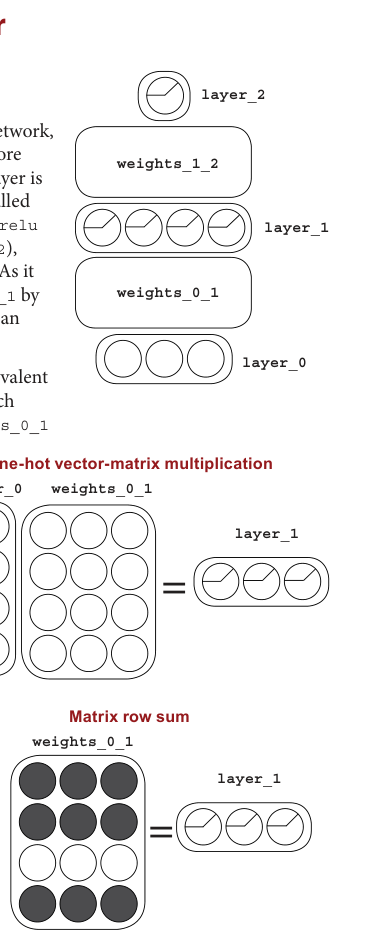

Proses memilih rows dan melakukan sum atau average berarti memperlakukan first linear layer (`weights_0_1`) sebagai embedding layer.

Secara struktur, linear layer dan embedding layer tetap sama. Perbedaannya hanya cara forward propagation dilakukan. Menjumlahkan sedikit rows jauh lebih cepat daripada mengalikan vector sparse besar.

In [3]:
import numpy as np
import sys

np.random.seed(1)

def sigmoid(x):
  return 1 / (1 + np.exp(-x))

alpha, iterations = (0.01, 2)
hidden_size = 100

weights_0_1 = 0.2 * np.random.random((len(vocab), hidden_size)) - 0.1
weights_1_2 = 0.2 * np.random.random((hidden_size, 1)) - 0.1

correct, total = (0, 0)

for iter in range(iterations):
  for i in range(len(input_dataset) - 1000):
    x, y = (input_dataset[i], target_dataset[i])

    layer_1 = sigmoid(np.sum(weights_0_1[x], axis=0))
    layer_2 = sigmoid(np.dot(layer_1, weights_1_2))

    layer_2_delta = layer_2 - y
    layer_1_delta = layer_2_delta.dot(weights_1_2.T)

    weights_0_1[x] -= layer_1_delta * alpha
    weights_1_2 -= np.outer(layer_1, layer_2_delta) * alpha

    if np.abs(layer_2_delta) < 0.5:
      correct += 1

    total += 1

    if i % 1000 == 999:
      progress = str(i / float(len(input_dataset)))
      sys.stdout.write(
        "\rIter:" + str(iter) +
        " Progress:" + progress[2:4] + "." + progress[4:6] +
        "% Training Accuracy:" + str(correct / float(total)) + "%"
      )

  print()

correct, total = (0, 0)

for i in range(len(input_dataset) - 1000, len(input_dataset)):
  x = input_dataset[i]
  y = target_dataset[i]

  layer_1 = sigmoid(np.sum(weights_0_1[x], axis=0))
  layer_2 = sigmoid(np.dot(layer_1, weights_1_2))

  if np.abs(layer_2 - y) < 0.5:
    correct += 1

  total += 1

print("Test Accuracy:" + str(correct / float(total)))

NameError: name 'vocab' is not defined

## Interpreting the output

Network mencari correlation antara input datapoints dan output datapoints.

Pada model movie reviews, setiap review direpresentasikan sebagai vocabulary, lalu network diminta memprediksi salah satu dari dua labels: positive atau negative.

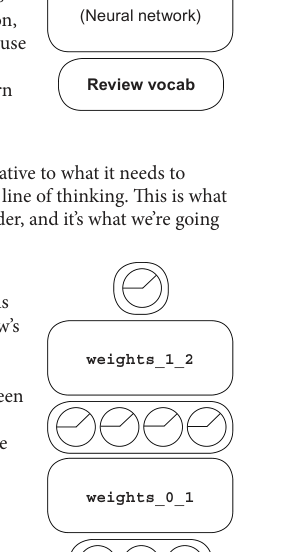

Berdasarkan correlation summarization, network minimal akan menemukan words yang memiliki positive atau negative correlation terhadap label. Namun, ini belum berarti network memahami semua pattern bahasa yang berguna.

## Neural architecture

Architecture memengaruhi hal yang dipelajari network.

Direct correlation antara input dataset dan target dataset dapat ditemukan oleh two-layer network. Namun, model pada chapter ini memakai hidden layer. Hidden layer pada dasarnya mengelompokkan datapoints dari layer sebelumnya ke dalam sejumlah group.

Setiap hidden neuron menjawab pertanyaan: apakah datapoint ini masuk ke group saya?

Grouping berguna jika memenuhi dua hal:

- Grouping berguna untuk memprediksi output label.
- Grouping merepresentasikan fenomena nyata dalam data yang penting.

Untuk sentiment prediction, memahami perbedaan antara `terrible` dan `not terrible` akan berguna. Namun, karena input network hanya vocabulary review, kalimat “it was great, not terrible” dan “it was terrible, not great” dapat menghasilkan representasi yang sama. Karena itu, architecture ini kecil kemungkinan memahami negation.

Sebuah layer kemungkinan tidak akan menemukan pattern tertentu jika dua example dengan pattern berbeda menghasilkan hidden layer yang sama.

Pada level granular, setiap neuron mengklasifikasikan datapoint sebagai masuk atau tidak masuk ke group-nya. Pada level lebih tinggi, dua movie reviews mirip jika keduanya masuk ke banyak group yang sama. Dua words mirip jika weights yang menghubungkannya ke hidden neurons juga mirip.

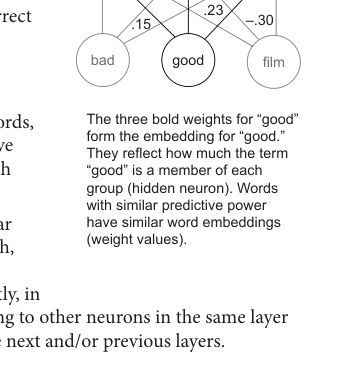

Weights untuk sebuah word membentuk embedding word tersebut. Words dengan predictive power yang mirip akan memiliki word embeddings yang mirip.

## Comparing word embeddings

Similarity antar word embeddings dapat dilihat dengan membandingkan row `weights_0_1` untuk setiap word.

Setiap row pada `weights_0_1` berisi weights dari sebuah word ke hidden neurons. Untuk mencari words yang paling mirip dengan target word, vector target word dibandingkan dengan vector word lain menggunakan Euclidean distance.

In [ ]:
from collections import Counter
import math

def similar(target="beautiful"):
  target_index = word2index[target]
  scores = Counter()

  for word, index in word2index.items():
    raw_difference = weights_0_1[index] - weights_0_1[target_index]
    squared_difference = raw_difference * raw_difference
    scores[word] = -math.sqrt(sum(squared_difference))

  return scores.most_common(10)

if "beautiful" in word2index:
  print(similar("beautiful"))

if "terrible" in word2index:
  print(similar("terrible"))

Term yang paling mirip dengan sebuah word biasanya adalah word itu sendiri, lalu words lain yang memiliki usefulness serupa untuk target label.

Karena network hanya memiliki dua labels, yaitu positive dan negative, input terms cenderung dikelompokkan berdasarkan label yang mereka prediksi.

## What is the meaning of a neuron?

Meaning pada network ditentukan oleh target labels yang diprediksi.

Words yang terlihat mirip menurut network tidak selalu sama dengan makna real-world manusia. Misalnya, pada task sentiment, dua words bisa dianggap mirip karena keduanya sama-sama membantu memprediksi positive review, walaupun secara linguistik berbeda.

Artinya, meaning dalam neural network sepenuhnya dikontekstualisasikan oleh correlation summarization terhadap task yang sedang diprediksi.

Agar network belajar meaning yang lebih nuanced, input dan target data harus menuntut pemahaman bahasa yang lebih nuanced. Chapter ini menggunakan task **fill in the blank**, yaitu menghapus satu word dari phrase lalu melatih network untuk memprediksi word yang hilang berdasarkan context.

## Filling in the blank

Task ini belajar richer meanings untuk words karena signal yang dipelajari lebih kaya.

Network mengambil phrase lima kata, menghapus satu focus term, lalu mencoba memprediksi identity dari word yang dihapus menggunakan sisa phrase.

Untuk mempercepat training, digunakan teknik **negative sampling**. Karena memprediksi semua possible words akan membutuhkan banyak labels dan lambat, network hanya memprediksi satu target benar dan beberapa negative samples acak pada setiap forward propagation.

In [4]:
import sys
import random
import math
from collections import Counter
import numpy as np

np.random.seed(1)
random.seed(1)

reviews_path, labels_path = ensure_review_files()

with open(reviews_path, "r", encoding="utf-8") as f:
  raw_reviews = f.readlines()

tokens = list(map(lambda x: x.split(" "), raw_reviews))

wordcnt = Counter()

for sent in tokens:
  for word in sent:
    wordcnt[word] -= 1

vocab = list(set(map(lambda x: x[0], wordcnt.most_common())))

word2index = {}

for i, word in enumerate(vocab):
  word2index[word] = i

concatenated = []
input_dataset = []

for sent in tokens:
  sent_indices = []

  for word in sent:
    try:
      sent_indices.append(word2index[word])
      concatenated.append(word2index[word])
    except Exception:
      pass

  input_dataset.append(sent_indices)

concatenated = np.array(concatenated)
random.shuffle(input_dataset)

print("Jumlah review:", len(input_dataset))
print("Ukuran vocab:", len(vocab))
print("Jumlah token:", len(concatenated))

Upload file reviews.txt dan labels.txt dari dataset chapter ini.


FileNotFoundError: reviews.txt dan labels.txt belum ditemukan. Letakkan kedua file tersebut di working directory Colab, lalu jalankan ulang cell ini.

In [5]:
alpha, iterations = (0.05, 2)
hidden_size, window, negative = (50, 2, 5)

weights_0_1 = (np.random.rand(len(vocab), hidden_size) - 0.5) * 0.2
weights_1_2 = np.random.rand(len(vocab), hidden_size) * 0

layer_2_target = np.zeros(negative + 1)
layer_2_target[0] = 1

def similar(target="beautiful"):
  target_index = word2index[target]
  scores = Counter()

  for word, index in word2index.items():
    raw_difference = weights_0_1[index] - weights_0_1[target_index]
    squared_difference = raw_difference * raw_difference
    scores[word] = -math.sqrt(sum(squared_difference))

  return scores.most_common(10)

def sigmoid(x):
  return 1 / (1 + np.exp(-x))

for rev_i, review in enumerate(input_dataset * iterations):
  for target_i in range(len(review)):
    target_samples = [review[target_i]] + list(
      concatenated[(np.random.rand(negative) * len(concatenated)).astype("int").tolist()]
    )

    left_context = review[max(0, target_i - window):target_i]

    # Teks chapter menyebut five-word phrase: 2 kiri + target + 2 kanan.
    # Karena slicing Python exclusive di kanan, end index perlu +1.
    right_context = review[target_i + 1:min(len(review), target_i + window + 1)]

    context = left_context + right_context

    if len(context) == 0:
      continue

    layer_1 = np.mean(weights_0_1[context], axis=0)
    layer_2 = sigmoid(layer_1.dot(weights_1_2[target_samples].T))

    layer_2_delta = layer_2 - layer_2_target
    layer_1_delta = layer_2_delta.dot(weights_1_2[target_samples])

    weights_0_1[context] -= layer_1_delta * alpha
    weights_1_2[target_samples] -= np.outer(layer_2_delta, layer_1) * alpha

  if rev_i % 250 == 0:
    progress = rev_i / float(len(input_dataset) * iterations)
    sys.stdout.write("\rProgress:" + str(progress))

print()

if "terrible" in word2index:
  print(similar("terrible"))

if "beautiful" in word2index:
  print(similar("beautiful"))

NameError: name 'vocab' is not defined

Pada kode buku, `right_context` memakai slicing yang hanya mengambil satu kata kanan saat `window = 2`. Karena penjelasan task menyebut five-word phrase, notebook ini memakai `target_i + window + 1` agar context kanan berisi sampai dua words.

## Meaning is derived from loss

Dengan network baru, word embeddings dikelompokkan dengan cara yang berbeda.

Sebelumnya, words dikelompokkan berdasarkan kemungkinan memprediksi positive atau negative label. Pada fill-in-the-blank, words dikelompokkan berdasarkan kemungkinan muncul dalam phrase yang sama.

Artinya, network yang mirip dan dataset yang sama dapat belajar property berbeda jika target prediction atau loss function berbeda.

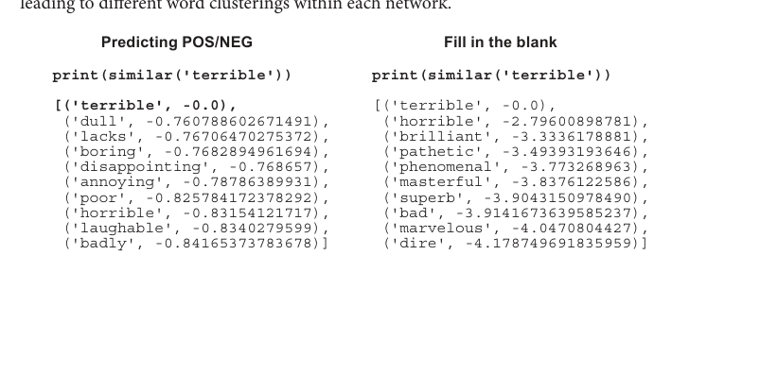

Proses memilih hal yang ingin dipelajari network dengan mengatur input dan target values disebut di chapter ini sebagai **intelligence targeting**.

Input/target values bukan satu-satunya cara melakukan intelligence targeting. Kita juga dapat mengubah error measure, size dan types of layers, serta regularization. Dalam deep learning research, teknik-teknik ini termasuk dalam konstruksi **loss function**.

Neural networks tidak benar-benar “belajar data”; neural networks meminimalkan loss function.

Learning dapat dilihat sebagai proses mengatur weights agar error turun menuju 0. Namun, jika dilihat lebih luas, yang benar-benar ditentukan adalah loss function. Loss function mencakup forward propagation dan raw error evaluation.

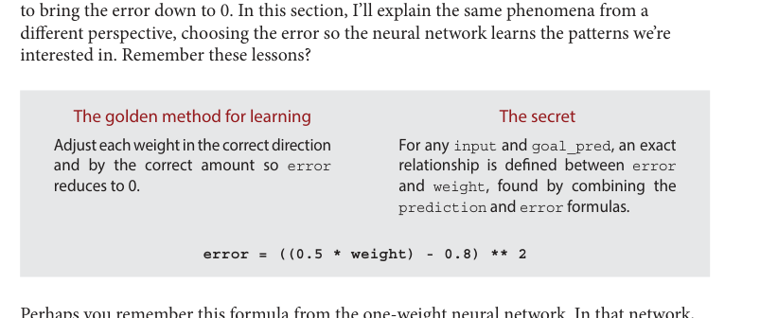

Dua neural networks dapat memiliki starting weights yang sama dan dilatih pada dataset yang sama, tetapi belajar pattern berbeda jika loss function-nya berbeda. Dalam contoh movie review, loss function berbeda karena target values berbeda: positive/negative versus fill in the blank.

Jika network tidak belajar dengan baik, solusinya sering berada pada loss function, termasuk architecture, layers, regularization, dataset, nonlinearities, dan cara error dihitung.

## King – Man + Woman ~= Queen

Word analogies adalah konsekuensi menarik dari word embeddings.

Jika network fill-in-the-blank dilatih pada corpus yang cukup besar, vector untuk words dapat dioperasikan secara aljabar. Contoh terkenal:

`king - man + woman ~= queen`

Di movie reviews, analogies juga dapat muncul dalam bentuk lain, misalnya:

`terrible - bad + good ~= superb`

In [6]:
def analogy(positive=["terrible", "good"], negative=["bad"]):
  norms = np.sum(weights_0_1 * weights_0_1, axis=1)
  norms.resize(norms.shape[0], 1)

  normed_weights = weights_0_1 * norms

  query_vect = np.zeros(len(weights_0_1[0]))

  for word in positive:
    if word in word2index:
      query_vect += normed_weights[word2index[word]]

  for word in negative:
    if word in word2index:
      query_vect -= normed_weights[word2index[word]]

  scores = Counter()

  for word, index in word2index.items():
    raw_difference = weights_0_1[index] - query_vect
    squared_difference = raw_difference * raw_difference
    scores[word] = -math.sqrt(sum(squared_difference))

  return scores.most_common(10)[1:]

print(analogy(["terrible", "good"], ["bad"]))

if "elizabeth" in word2index and "he" in word2index and "she" in word2index:
  print(analogy(["elizabeth", "he"], ["she"]))

NameError: name 'weights_0_1' is not defined

## Word analogies

Word analogies adalah linear compression dari property yang sudah ada dalam data.

Jika word embedding dibayangkan memiliki dua dimensions, analogy dapat dipahami sebagai pergeseran vector. Misalnya, perbedaan antara `king` dan `man` menyisakan arah “royalty”. Perbedaan antara `queen` dan `woman` juga mengandung arah yang mirip.

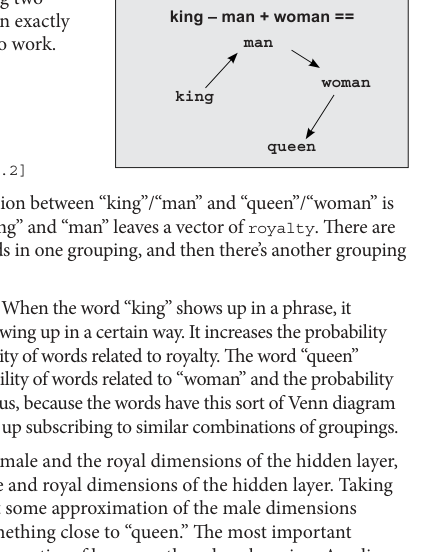

Ketika word `king` muncul dalam phrase, ia meningkatkan probability words yang berkaitan dengan `man` dan words yang berkaitan dengan royalty. Word `queen` meningkatkan probability words yang berkaitan dengan `woman` dan words yang berkaitan dengan royalty.

Karena words memiliki efek Venn diagram terhadap output probability, embeddings mereka berlangganan kombinasi groupings yang mirip. Secara sederhana, `king` mengandung male + royal dimensions, sedangkan `queen` mengandung female + royal dimensions.

Hal pentingnya: fenomena ini lebih banyak berasal dari property bahasa daripada deep learning itu sendiri. Linear compression terhadap co-occurrence statistics dapat menunjukkan perilaku serupa.

## Summary

Chapter ini membahas neural word embeddings dan dampak loss terhadap learning.

Pembahasan dimulai dari NLP dan task-task dasarnya, lalu menunjukkan bagaimana neural networks memodelkan language pada level word menggunakan word embeddings. Pilihan loss function menentukan property yang ditangkap oleh embeddings. Dengan target positive/negative, words dikelompokkan berdasarkan sentiment. Dengan fill-in-the-blank, words dikelompokkan berdasarkan context dan co-occurrence.

Chapter ini juga membahas word analogies sebagai fenomena menarik dari word embeddings.